# Synthetic Data Experiment Series

## 01 - Cylindrical Mixture

This notebook samples synthetic data from a **mixture of Cylindrical distributions** (`d_gauss=3`, `d_vmf=3`).

Then compares a mixture of Cylindrical and a mixture-of-mixtures perfomances in learning such data.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

%matplotlib widget
import soccer_pattern_recognition as spr
from experiment.synthetic_data import experiment_helper as mod


rng = np.random.RandomState(7)
D_GAUSS = mod.D_GAUSS
D_VMF = mod.D_VMF
N = 10000

### Data Generation

In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        norm = np.linalg.norm(v)
        return v / max(norm, 1e-12)
    else:
        norm = np.linalg.norm(v, axis=-1, keepdims=True)
        return v / np.clip(norm, 1e-12, None)

In [3]:
# --- 1) Mixture of Cylindrical distributions (d=3, d=3) ---
cyl_components = [
    spr.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.0, 0.0, 0.0]),
        cross_cov=np.array([[ 0.45, -0.10,  0.20],
                            [ 0.05,  0.30, -0.15],
                            [-0.25,  0.10,  0.35]]),
        cond_cov=np.array([[2.20, 0.75, 0.40],
                           [0.75, 0.55, 0.10],
                           [0.40, 0.10, 0.25]]),
        mu_vmf=unit([1.0, 0.0, 0.0]),
        kappa=9.0,
    ),

    spr.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.0, 0.0, 0.0]),   # same Gaussian mean
        cross_cov=np.array([[-0.30,  0.20,  0.10],
                            [ 0.15, -0.25,  0.05],
                            [ 0.10,  0.05, -0.20]]),
        cond_cov=np.array([[0.75, 0.05, 0.00],
                           [0.05, 0.85, 0.08],
                           [0.00, 0.08, 0.70]]),   # much more isotropic
        mu_vmf=unit([0.0, 1.0, 0.0]),
        kappa=9.0,
    ),

    spr.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([2.3, 1.2, -1.0]),
        cross_cov=np.array([[ 0.10,  0.15, -0.20],
                            [-0.05,  0.25,  0.18],
                            [ 0.20, -0.10,  0.12]]),
        cond_cov=np.array([[0.95, 0.18, -0.05],
                           [0.18, 1.05, 0.12],
                           [-0.05, 0.12, 0.80]]),
        mu_vmf=unit([0.0, 0.0, 1.0]),
        kappa=5.5,
    ),
]

cyl_weights = np.array([0.35, 0.35, 0.30], dtype=float)

cyl_mixture = spr.MixtureModel(components=cyl_components,
                               weights=cyl_weights,
                               init="k-means",
                               rng=rng)

x = cyl_mixture.sample(N, rng=rng)

In [4]:
x_gauss = x[:, :D_GAUSS]
x_vmf = x[:, D_GAUSS:]

In [5]:
# medium noise setup
sigma_g = 0.15 * np.maximum(x_gauss.std(axis=0, ddof=1), 1e-8)
sigma_v = 0.05

noise_g = rng.normal(0.0, sigma_g, size=(N, D_GAUSS))
noise_v = rng.normal(0.0, sigma_v, size=(N, D_VMF))

x_noisy_gauss = noise_g + x_gauss
x_noisy_vmf = noise_v + x_vmf

# re-project directional block to unit sphere (required for vMF)
x_noisy_vmf = unit(x_noisy_vmf)
x_noisy = np.concatenate((x_noisy_gauss, x_noisy_vmf), axis=1)

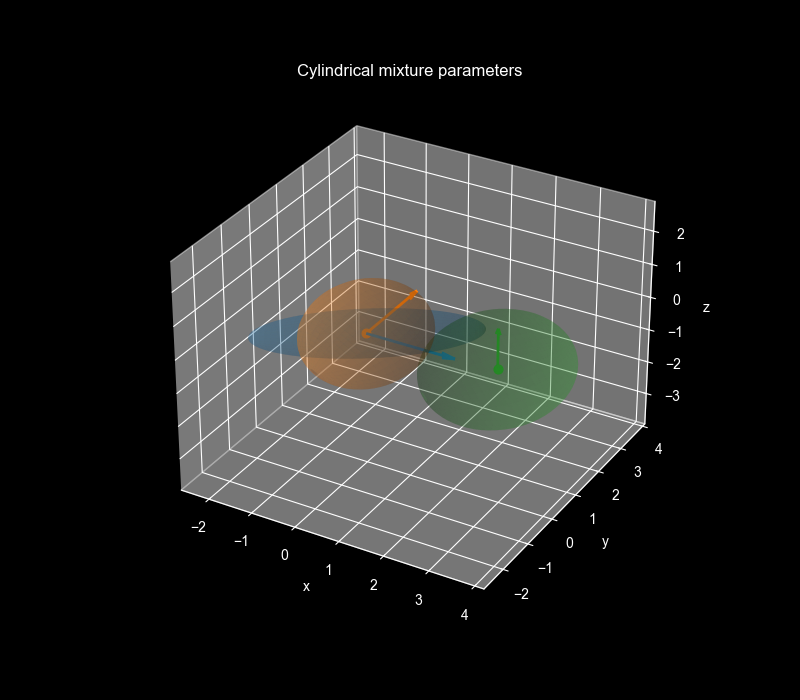

In [6]:
fig, ax = mod.plot_cylindrical_components(cyl_mixture, arrow_scale=2.0)

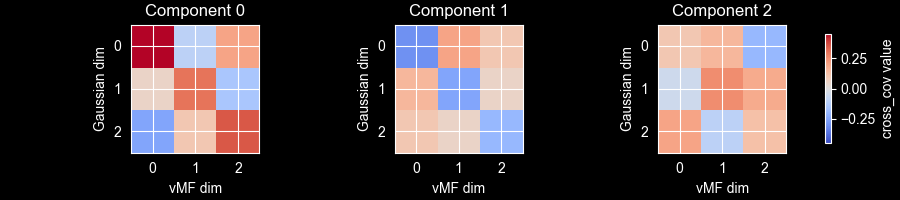

In [7]:
mod.plot_cross_cov_matrices(cyl_mixture.components, cmap="coolwarm")

### Model Training

In [8]:
search = spr.calibrate_mixture_by_bic_grid_search(
    x,
    n_components_grid=(2, 3, 4),
    n_restarts=2,
    init="k-means++",
    model_builder=mod.cylindrical_mixture_builder_3d,
    tol=1e-4,
    max_iter=300,
    m_step_case="bregman",
    random_state=42,
)

cyl_mm = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 110867.26940443857
Best config: {'n_components': 3, 'restart': 1, 'seed': 787846414, 'n_iter': 17}


In [9]:
search = spr.calibrate_mixture_by_bic_grid_search(
    x_noisy,
    n_components_grid=(2, 3, 4),
    n_restarts=2,
    init="k-means++",
    model_builder=mod.cylindrical_mixture_builder_3d,
    tol=1e-4,
    max_iter=300,
    m_step_case="bregman",
    random_state=42,
)

noisy_cyl_mm = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 114399.61692920203
Best config: {'n_components': 3, 'restart': 1, 'seed': 787846414, 'n_iter': 17}


In [10]:
search = spr.calibrate_mom_by_bic_grid_search(
    layer1_data=x_gauss,
    layer2_data=x_vmf,
    n_layer1_grid=(2, 3, 4),
    n_layer2_grid=(1, 2),
    n_restarts=3,
    init_layer1="k-means++",
    init_layer2="k-means++",
    model_builder=mod.mom_builder_3d,
    m_step_case="bregman",
    tol=1e-4,
    max_iter=300,
    random_state=42,
)

cyl_mom = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 126505.40380003302
Best config: {'n_layer1_components': 4, 'n_layer2_components': 2, 'restart': 0, 'seed': 1433267572, 'n_iter': 102}


In [11]:
search = spr.calibrate_mom_by_bic_grid_search(
    layer1_data=x_noisy_gauss,
    layer2_data=x_noisy_vmf,
    n_layer1_grid=(2, 3, 4),
    n_layer2_grid=(1, 2),
    n_restarts=3,
    init_layer1="k-means++",
    init_layer2="k-means++",
    model_builder=mod.mom_builder_3d,
    m_step_case="bregman",
    tol=1e-4,
    max_iter=300,
    random_state=42,
)

noisy_cyl_mom = search["best_model"]
print("Best BIC:", search["best_bic"])
print("Best config:", search["best_config"])

Best BIC: 127996.53860148982
Best config: {'n_layer1_components': 4, 'n_layer2_components': 2, 'restart': 0, 'seed': 1433267572, 'n_iter': 106}


### Model Comparison

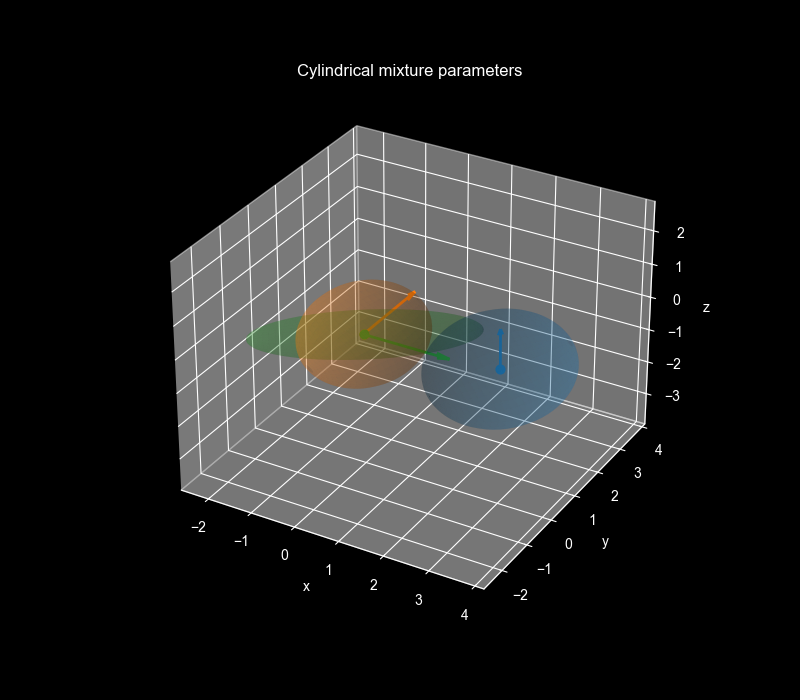

In [12]:
fig, ax = mod.plot_cylindrical_components(cyl_mm, arrow_scale=2.0)

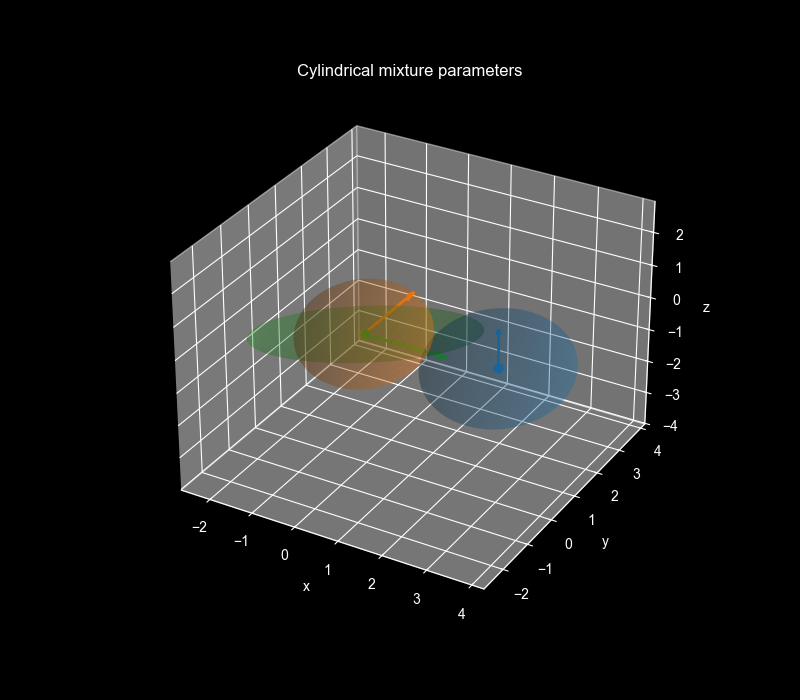

In [13]:
fig, ax = mod.plot_cylindrical_components(noisy_cyl_mm, arrow_scale=2.0)

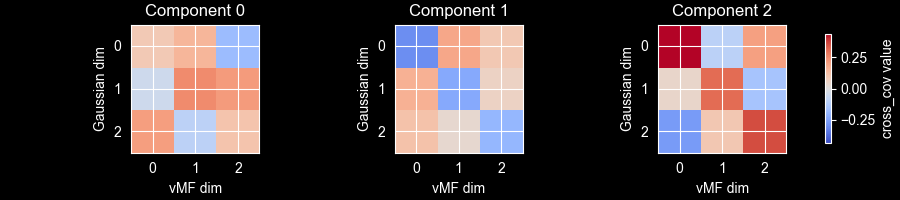

In [14]:
mod.plot_cross_cov_matrices(cyl_mm.components, cmap="coolwarm")

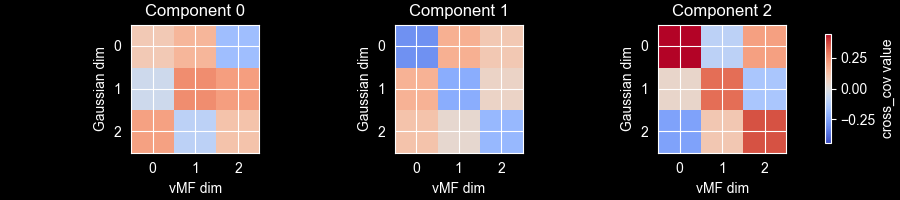

In [15]:
mod.plot_cross_cov_matrices(noisy_cyl_mm.components, cmap="coolwarm")

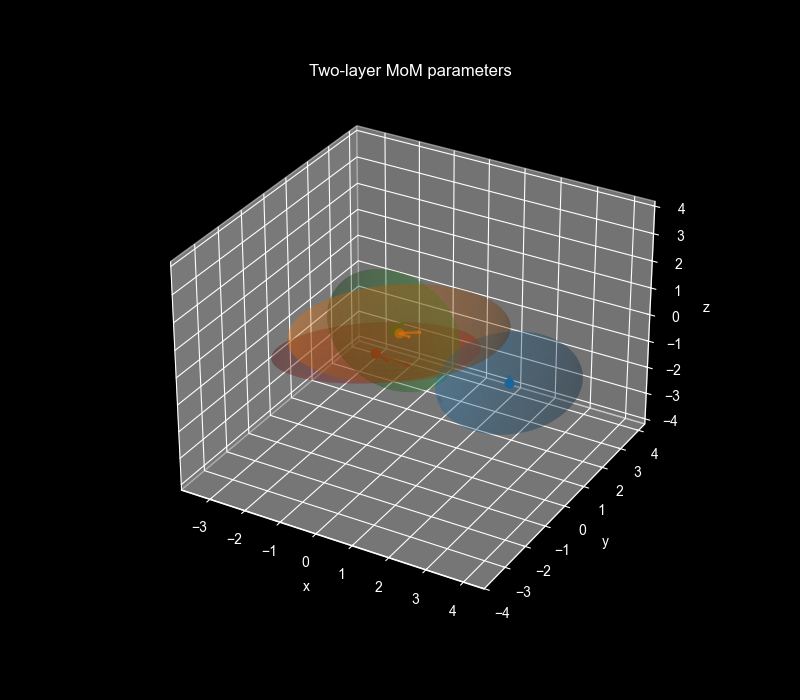

In [16]:
fig, ax = mod.plot_mom_components(cyl_mom, arrow_scale=2.0)

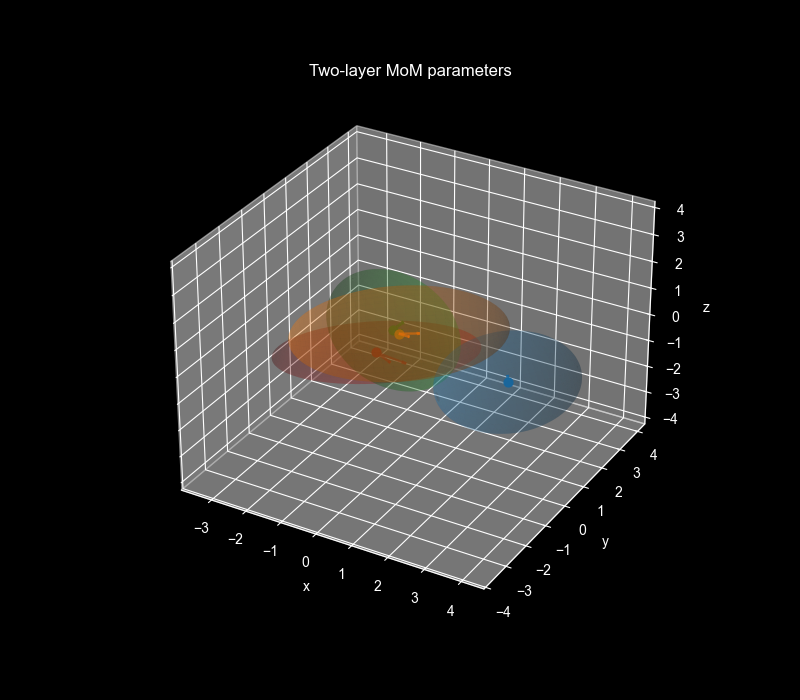

In [17]:
fig, ax = mod.plot_mom_components(noisy_cyl_mom, arrow_scale=2.0)

In [18]:
print(f"Cyl. Mixture BIC: {cyl_mm.bic_score(x):.2f}")
print(f"MoM BIC: {cyl_mom.bic_score(x_gauss, x_vmf):.2f}")
print(f"Cyl. Mixture Log-likelihood: {cyl_mm.log_pdf(x).sum():.2f}")
print(f"MoM Log-likelihood: {cyl_mom.log_pdf(x_gauss, x_vmf).sum():.2f}")

print(f"Noisy Cyl. Mixture BIC: {noisy_cyl_mm.bic_score(x_noisy):.2f}")
print(f"Noisy MoM BIC: {noisy_cyl_mom.bic_score(x_noisy_gauss, x_noisy_vmf):.2f}")
print(f"Noisy Cyl. Mixture Log-likelihood: {noisy_cyl_mm.log_pdf(x_noisy).sum():.2f}")
print(f"Noisy MoM Log-likelihood: {noisy_cyl_mom.log_pdf(x_noisy_gauss, x_noisy_vmf).sum():.2f}")

Cyl. Mixture BIC: 110867.27
MoM BIC: 126505.40
Cyl. Mixture Log-likelihood: -55134.30
MoM Log-likelihood: -62944.16
Noisy Cyl. Mixture BIC: 114399.62
Noisy MoM BIC: 127996.54
Noisy Cyl. Mixture Log-likelihood: -56900.47
Noisy MoM Log-likelihood: -63689.72
